Loading datasets...
Combined X shape = (11240, 320)
    SGD-MDS may not have converged: stress changed by -2.7% in final iterations. Consider increasing n_iter or adjusting learning_rate.
2025-11-04 23:15:05,966 - INFO - Epoch 0/100 - Recon Loss: 0.5934777 - Geo Loss: 0.0011882
2025-11-04 23:15:12,507 - INFO - Epoch 50/100 - Recon Loss: 0.1304800 - Geo Loss: 0.0004778


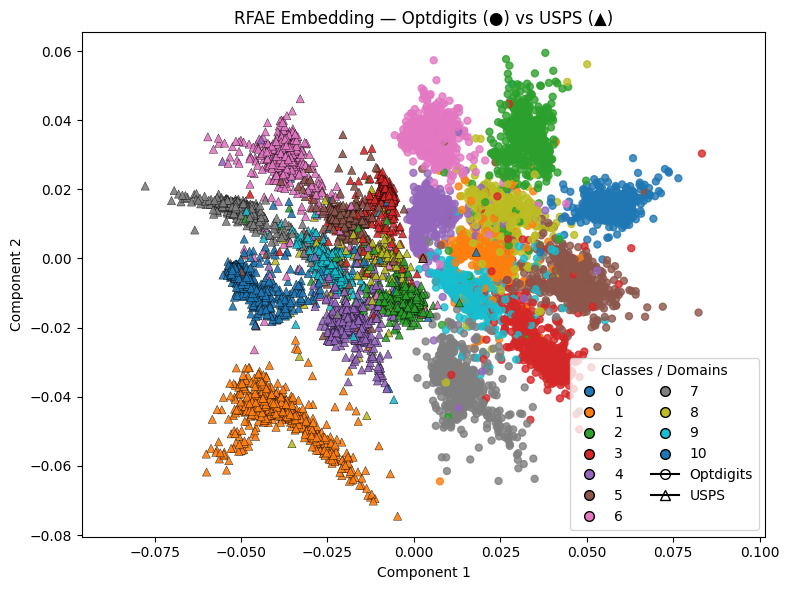

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import MinMaxScaler
from rfae import RFAE

# ---------------------------------------------------------
# 1️⃣ Load datasets
# ---------------------------------------------------------
print("Loading datasets...")
optdigits = fetch_openml("optdigits", version=1, as_frame=False)
usps = fetch_openml("usps", version=2, as_frame=False)

X_opt = optdigits.data.astype(float)
y_opt = optdigits.target.astype(int)

X_usps = usps.data.astype(float)
y_usps = usps.target.astype(int)

# Normalize both to [0, 1]
scaler = MinMaxScaler()
X_opt = scaler.fit_transform(X_opt)
X_usps = scaler.fit_transform(X_usps)

# Equalize number of samples
n_samples = min(len(X_opt), len(X_usps))
X_opt, y_opt = X_opt[:n_samples], y_opt[:n_samples]
X_usps, y_usps = X_usps[:n_samples], y_usps[:n_samples]

# ---------------------------------------------------------
# 2️⃣ Construct complementary feature space
# ---------------------------------------------------------
n_feat_opt = X_opt.shape[1]   # 64
n_feat_usps = X_usps.shape[1] # 256

# Optdigits domain (A): first 64 real features, 256 NaNs
X_A = np.concatenate([X_opt, np.full((n_samples, n_feat_usps), np.nan)], axis=1)

# USPS domain (B): first 64 NaNs, then 256 real features
X_B = np.concatenate([np.full((n_samples, n_feat_opt), np.nan), X_usps], axis=1)

# Combine
X = np.vstack([X_A, X_B])
y = np.concatenate([y_opt, y_usps])
domains = np.concatenate([np.zeros(n_samples, int), np.ones(n_samples, int)])

print(f"Combined X shape = {X.shape}")  # (2N, 320)

# ---------------------------------------------------------
# 3️⃣ Fit RFAE on combined data
# ---------------------------------------------------------
model = RFAE(
    random_state=42,
    device="mps",
    epochs=100,
    lam=0.1,
    embedder_params={"prox_method": "rfgap"},
)
embeddings = model.fit_transform(X, y)

# ---------------------------------------------------------
# 4️⃣ Visualization (color = label, shape = domain)
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))

# Optdigits (circles)
plt.scatter(
    embeddings[domains == 0, 0],
    embeddings[domains == 0, 1],
    c=y[domains == 0],
    cmap="tab10",
    s=25, alpha=0.8,
    marker="o",
    label="Optdigits"
)

# USPS (triangles)
plt.scatter(
    embeddings[domains == 1, 0],
    embeddings[domains == 1, 1],
    c=y[domains == 1],
    cmap="tab10",
    s=35, alpha=0.9,
    marker="^",
    edgecolors="k",
    linewidths=0.3,
    label="USPS"
)

plt.title("RFAE Embedding — Optdigits (●) vs USPS (▲)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.axis("equal")

# Legend: color = class, shape = domain
classes = np.unique(y)
cmap = plt.get_cmap("tab10")
class_handles = [
    plt.Line2D([0], [0], marker="o", color="none",
               markerfacecolor=cmap(i % 10), markersize=7, label=str(cls))
    for i, cls in enumerate(classes)
]

domain_handles = [
    plt.Line2D([0], [0], marker="o", color="k", markerfacecolor="none",
               markersize=7, label="Optdigits"),
    plt.Line2D([0], [0], marker="^", color="k", markerfacecolor="none",
               markersize=7, label="USPS")
]

plt.legend(handles=class_handles + domain_handles,
           title="Classes / Domains",
           loc="best", frameon=True, ncol=2)
plt.tight_layout()
plt.show()